# 12 — B-spline coefficient multicollinearity diagnostics

**Goal.** Empirically measure multicollinearity in the L2-normalised B-spline
feature vectors that the production grid scripts (`08_kbp_krp_grid_{lr,rf,svm,xgb}.py`)
feed into the classifiers, so the thesis can make a *data-driven* statement
about multicollinearity instead of relying on a textbook claim that classifiers
are "theoretically robust" to it.

**Scope.** The production B-spline grid sweeps `K_BP, K_RP ∈ {4, ..., 20}`
(see `BSPLINE_MIN_K = 4` and `range(1, 21)` in `08_kbp_krp_grid_lr.py`). This
notebook covers five headline symmetric cells inside that range:

$$K \in \{4,\ 8,\ 12,\ 16,\ 20\}$$

For each $K$ we build the same `(n=2815, 2K)` L2-normalised concatenated
`[BP | RP]` feature matrix the classifiers consume (via
`step02.build_block_fit(..., 'bspline', 'none', K)` + `_common.l2_normalize`),
and compute three multicollinearity diagnostics:

1. **Pearson correlation matrix** — off-diagonal $|r|$ mean / median / max /
   95th percentile, plus a count of pairs with $|r| > 0.7$ and $|r| > 0.9$.
2. **Variance Inflation Factors** — $\mathrm{VIF}_j = (\Sigma^{-1})_{jj}$
   where $\Sigma$ is the correlation matrix. Conventional thresholds:
   $\mathrm{VIF} > 5$ is "moderate", $> 10$ is "severe".
3. **Condition number** $\kappa = \sigma_{\max}/\sigma_{\min}$ from the SVD
   of the feature matrix. Conventional thresholds: $\kappa > 30$ "serious",
   $> 100$ "severe".

Outputs are written to `results/`:

- `bspline_multicollinearity_summary.csv`
- `bspline_correlation_heatmaps.{pdf,png}`
- `bspline_vif_condition_vs_k.{pdf,png}`

In [1]:
from __future__ import annotations

import sys
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name != "bp_rp_basis_experiment":
    candidate = ROOT / "bp_rp_basis_experiment"
    if candidate.exists():
        ROOT = candidate
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sys.modules.pop("bp_basis_step02", None)
_spec = spec_from_file_location("bp_basis_step02", ROOT / "02_generate_basis_features.py")
step02 = module_from_spec(_spec)
assert _spec.loader is not None
sys.modules[_spec.name] = step02
_spec.loader.exec_module(step02)

from _common import (
    BP_SAMPLED_CSV,
    RESULTS_DIR,
    RP_SAMPLED_CSV,
    l2_normalize,
)

K_LIST = [4, 8, 12, 16, 20]
BASIS = "bspline"
SMOOTHING = "none"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"ROOT          : {ROOT}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"K values      : {K_LIST}")

ROOT          : /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment
RESULTS_DIR   : /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results
K values      : [4, 8, 12, 16, 20]


## Build the feature matrices

Same pipeline as `08_kbp_krp_grid_lr.generate_features` (lines 173–184):

1. `step02.load_block(BP_SAMPLED_CSV)` / `RP_SAMPLED_CSV` — raw sampled
   spectra (2815 sources × wavelength columns).
2. `step02.build_block_fit(block, 'bspline', 'none', K)` — least-squares fit
   of a cubic B-spline basis with `K` coefficients per arm.
3. `np.hstack([bp_coeffs, rp_coeffs])` → `(2815, 2K)` matrix.
4. `_common.l2_normalize` — row-wise unit norm on the concatenated vector
   (exactly what the production classifiers receive).

In [2]:
bp = step02.load_block(BP_SAMPLED_CSV)
rp = step02.load_block(RP_SAMPLED_CSV)
step02.check_alignment(bp, rp)

print(f"BP block      : {bp.flux.shape[0]} sources x {bp.flux.shape[1]} wavelengths")
print(f"RP block      : {rp.flux.shape[0]} sources x {rp.flux.shape[1]} wavelengths")


def build_concat_features(K: int) -> np.ndarray:
    """Replicates 08_kbp_krp_grid_lr.generate_features (symmetric K_BP=K_RP=K)."""
    bp_fit = step02.build_block_fit(bp, BASIS, SMOOTHING, K)
    rp_fit = step02.build_block_fit(rp, BASIS, SMOOTHING, K)
    stacked = np.hstack([bp_fit.coeffs, rp_fit.coeffs])
    cols = [f"c{i:03d}" for i in range(stacked.shape[1])]
    df = pd.DataFrame(stacked, columns=cols)
    df = l2_normalize(df, coeff_cols=cols)
    return df[cols].to_numpy(dtype=np.float64)


X_by_k: dict[int, np.ndarray] = {}
for K in K_LIST:
    X = build_concat_features(K)
    X_by_k[K] = X
    print(f"K = {K:2d}  ->  X shape {X.shape}")

BP block      : 2815 sources x 154 wavelengths
RP block      : 2815 sources x 193 wavelengths


K =  4  ->  X shape (2815, 8)


K =  8  ->  X shape (2815, 16)


K = 12  ->  X shape (2815, 24)


K = 16  ->  X shape (2815, 32)


K = 20  ->  X shape (2815, 40)


## Diagnostics

For each $K$ we compute:

- **Correlation matrix.** $\Sigma = \mathrm{corrcoef}(X^\top)$, then summarise
  the off-diagonal entries (mean / median / max / 95th percentile of $|r|$
  and counts of strong pairs).
- **VIF.** $\mathrm{VIF}_j = (\Sigma^{-1})_{jj}$. This is the standard
  identity that bypasses fitting $2K$ auxiliary regressions. If $\Sigma$ is
  numerically singular we fall back to the Moore–Penrose pseudoinverse and
  flag the row.
- **Condition number.** $\kappa = \sigma_{\max}/\sigma_{\min}$ from
  `np.linalg.svd(X, compute_uv=False)`. Computed on the centred feature
  matrix (per-column mean removal) so $\kappa$ reflects the column geometry,
  not the dominant mean.

In [3]:
def compute_diagnostics(X: np.ndarray, K: int) -> tuple[dict, np.ndarray, np.ndarray]:
    n_features = X.shape[1]
    assert n_features == 2 * K

    corr = np.corrcoef(X.T)

    mask = ~np.eye(n_features, dtype=bool)
    off = corr[mask]
    abs_off = np.abs(off)
    n_pairs = n_features * (n_features - 1) // 2

    try:
        inv_corr = np.linalg.inv(corr)
        vif_singular = False
    except np.linalg.LinAlgError:
        inv_corr = np.linalg.pinv(corr)
        vif_singular = True
    vif = np.diag(inv_corr)

    Xc = X - X.mean(axis=0, keepdims=True)
    sv = np.linalg.svd(Xc, compute_uv=False)
    sigma_max = float(sv.max())
    sigma_min = float(sv.min())
    cond_number = sigma_max / sigma_min if sigma_min > 0 else np.inf

    row = {
        "K": K,
        "n_features": n_features,
        "mean_abs_r": float(np.mean(abs_off)),
        "median_abs_r": float(np.median(abs_off)),
        "max_abs_r": float(np.max(abs_off)),
        "p95_abs_r": float(np.percentile(abs_off, 95)),
        "n_pairs_r_gt_0.7": int(np.sum(abs_off > 0.7) // 2),
        "n_pairs_r_gt_0.9": int(np.sum(abs_off > 0.9) // 2),
        "n_pairs_total": n_pairs,
        "mean_vif": float(np.mean(vif)),
        "max_vif": float(np.max(vif)),
        "n_vif_gt_5": int(np.sum(vif > 5)),
        "n_vif_gt_10": int(np.sum(vif > 10)),
        "vif_singular_fallback": vif_singular,
        "sigma_max": sigma_max,
        "sigma_min": sigma_min,
        "condition_number": float(cond_number),
    }
    return row, corr, vif


rows: list[dict] = []
corr_by_k: dict[int, np.ndarray] = {}
vif_by_k: dict[int, np.ndarray] = {}
for K in K_LIST:
    row, corr, vif = compute_diagnostics(X_by_k[K], K)
    rows.append(row)
    corr_by_k[K] = corr
    vif_by_k[K] = vif

summary = pd.DataFrame(rows)
summary_path = RESULTS_DIR / "bspline_multicollinearity_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved -> {summary_path}")
summary

Saved -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/bspline_multicollinearity_summary.csv


,K,n_features,mean_abs_r,median_abs_r,max_abs_r,p95_abs_r,n_pairs_r_gt_0.7,n_pairs_r_gt_0.9,n_pairs_total,mean_vif,max_vif,n_vif_gt_5,n_vif_gt_10,vif_singular_fallback,sigma_max,sigma_min,condition_number
0,4,8,0.447123,0.370531,0.960905,0.944547,6,2,28,60.168963,143.904057,8,8,False,6.997367,0.149286,46.872124
1,8,16,0.503394,0.532343,0.988403,0.913600,30,9,120,37.328936,95.115248,15,13,False,4.190622,0.087573,47.853150
2,12,24,0.518479,0.554119,0.987054,0.940414,84,18,276,36.509428,108.178736,23,17,False,4.131517,0.066618,62.018358
3,16,32,0.479985,0.479459,0.980031,0.919513,129,34,496,35.100909,157.405738,31,24,False,3.896600,0.047726,81.645345
4,20,40,0.431499,0.417052,0.997850,0.894926,147,36,780,54.867365,731.667738,38,30,False,4.284224,0.019637,218.172193


## Correlation heatmaps

One panel per $K$. The dashed line marks the BP $\to$ RP block boundary at
column index $K$. A *banded* pattern (strong correlation near the diagonal,
fading away from it) is the expected signature of B-splines, because their
compact local support means only neighbouring basis functions share much
support and therefore much covariance once projected onto data.

Saved -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/bspline_correlation_heatmaps.pdf
Saved -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/bspline_correlation_heatmaps.png


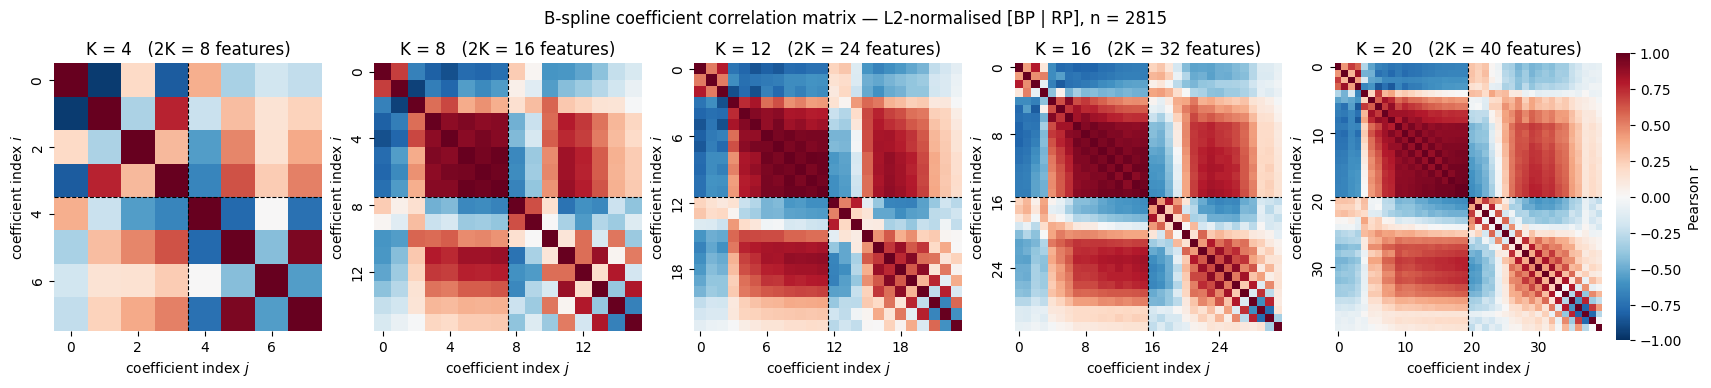

In [4]:
n_panels = len(K_LIST)
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(3.4 * n_panels, 3.6),
    constrained_layout=True,
)
if n_panels == 1:
    axes = [axes]

for ax, K in zip(axes, K_LIST):
    corr = corr_by_k[K]
    tick = max(1, K // 2)
    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdBu_r",
        center=0.0,
        vmin=-1.0,
        vmax=1.0,
        square=True,
        cbar=(K == K_LIST[-1]),
        cbar_kws={"label": "Pearson r", "shrink": 0.85} if K == K_LIST[-1] else None,
        xticklabels=tick,
        yticklabels=tick,
    )
    ax.axhline(K, color="black", linestyle="--", linewidth=0.8)
    ax.axvline(K, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"K = {K}   (2K = {2 * K} features)")
    ax.set_xlabel("coefficient index $j$")
    ax.set_ylabel("coefficient index $i$")

fig.suptitle(
    "B-spline coefficient correlation matrix — L2-normalised [BP | RP], n = 2815",
    y=1.04,
)

pdf_path = RESULTS_DIR / "bspline_correlation_heatmaps.pdf"
png_path = RESULTS_DIR / "bspline_correlation_heatmaps.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=160, bbox_inches="tight")
print(f"Saved -> {pdf_path}")
print(f"Saved -> {png_path}")
plt.show()

## VIF and condition number vs $K$

How do the headline multicollinearity numbers grow as we widen the basis?
Reference lines mark the conventional severity thresholds.

Saved -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/bspline_vif_condition_vs_k.pdf
Saved -> /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/results/bspline_vif_condition_vs_k.png


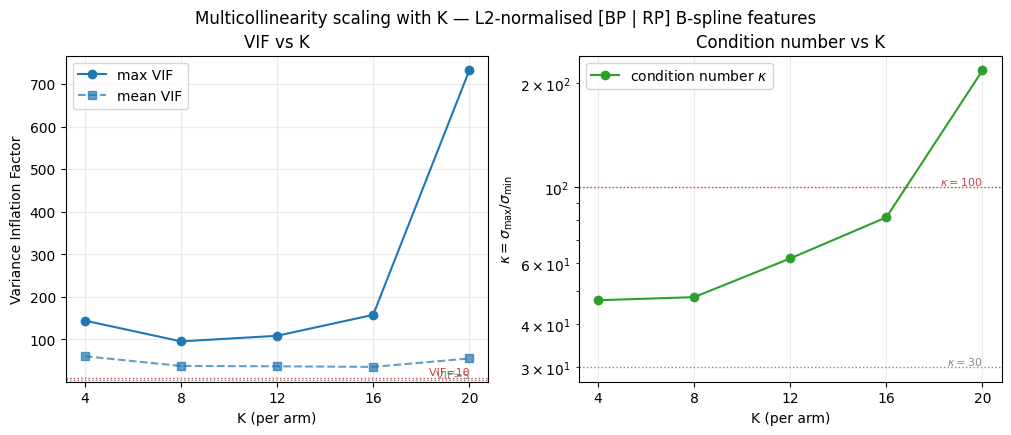

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ks = summary["K"].to_numpy()
max_vif = summary["max_vif"].to_numpy()
mean_vif = summary["mean_vif"].to_numpy()
cond = summary["condition_number"].to_numpy()
max_abs_r = summary["max_abs_r"].to_numpy()

ax = axes[0]
ax.plot(ks, max_vif, marker="o", color="#1f77b4", label="max VIF")
ax.plot(ks, mean_vif, marker="s", color="#1f77b4", linestyle="--", alpha=0.7, label="mean VIF")
ax.axhline(5, color="#888", linestyle=":", linewidth=1)
ax.axhline(10, color="#cc4444", linestyle=":", linewidth=1)
ax.text(ks[-1], 5, "  VIF=5", color="#888", va="bottom", ha="right", fontsize=8)
ax.text(ks[-1], 10, "  VIF=10", color="#cc4444", va="bottom", ha="right", fontsize=8)
ax.set_xlabel("K (per arm)")
ax.set_ylabel("Variance Inflation Factor")
ax.set_title("VIF vs K")
ax.set_xticks(ks)
ax.grid(alpha=0.25)
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(ks, cond, marker="o", color="#2ca02c", label=r"condition number $\kappa$")
ax.axhline(30, color="#888", linestyle=":", linewidth=1)
ax.axhline(100, color="#cc4444", linestyle=":", linewidth=1)
ax.text(ks[-1], 30, r"  $\kappa=30$", color="#888", va="bottom", ha="right", fontsize=8)
ax.text(ks[-1], 100, r"  $\kappa=100$", color="#cc4444", va="bottom", ha="right", fontsize=8)
ax.set_xlabel("K (per arm)")
ax.set_ylabel(r"$\kappa = \sigma_{\max}/\sigma_{\min}$")
ax.set_title("Condition number vs K")
ax.set_xticks(ks)
ax.grid(alpha=0.25)
ax.set_yscale("log")
ax.legend(loc="upper left")

fig.suptitle(
    "Multicollinearity scaling with K — L2-normalised [BP | RP] B-spline features",
    y=1.05,
)

pdf_path = RESULTS_DIR / "bspline_vif_condition_vs_k.pdf"
png_path = RESULTS_DIR / "bspline_vif_condition_vs_k.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=160, bbox_inches="tight")
print(f"Saved -> {pdf_path}")
print(f"Saved -> {png_path}")
plt.show()

## Auto-filled summary for the thesis

The cell below prints a paragraph with numbers pulled directly from the
summary table. Paste it into the thesis (or use it as a template) so the
statement about multicollinearity is grounded in measurements on the
production feature matrices, not a textbook citation.

In [6]:
def fmt_range(values: np.ndarray, fmt: str = "{:.3f}") -> str:
    lo = values.min()
    hi = values.max()
    return f"{fmt.format(lo)} (at K={int(summary.loc[values.argmin(), 'K'])}) "\
           f"to {fmt.format(hi)} (at K={int(summary.loc[values.argmax(), 'K'])})"


mean_r_range = fmt_range(summary["mean_abs_r"].to_numpy())
max_r_range = fmt_range(summary["max_abs_r"].to_numpy())
max_vif_range = fmt_range(summary["max_vif"].to_numpy(), "{:.2f}")
cond_range = fmt_range(summary["condition_number"].to_numpy(), "{:.1f}")
n_strong_max = int(summary["n_pairs_r_gt_0.7"].max())
n_strong_max_K = int(summary.loc[summary["n_pairs_r_gt_0.7"].idxmax(), "K"])
n_strong_max_total = int(summary.loc[summary["n_pairs_r_gt_0.7"].idxmax(), "n_pairs_total"])
n_vif_severe_max = int(summary["n_vif_gt_10"].max())
cond_max = float(summary["condition_number"].max())
cond_max_K = int(summary.loc[summary["condition_number"].idxmax(), "K"])

paragraph = (
    f"On the 2815-source training set, the L2-normalised concatenated\n"
    f"[BP | RP] B-spline feature matrix exhibits the expected banded\n"
    f"correlation structure due to the compact local support of cubic\n"
    f"B-splines. Across the production grid range K in {{{', '.join(map(str, K_LIST))}}}\n"
    f"the mean off-diagonal |r| ranges from {mean_r_range}, the maximum\n"
    f"|r| from {max_r_range}, and the maximum Variance Inflation Factor\n"
    f"from {max_vif_range}. The condition number of the centred feature\n"
    f"matrix ranges from {cond_range}, reaching {cond_max:.1f} at K = {cond_max_K}.\n"
    f"At the worst K value the count of strongly correlated pairs\n"
    f"(|r| > 0.7) is {n_strong_max} out of {n_strong_max_total} ({100 * n_strong_max / n_strong_max_total:.1f}%),\n"
    f"and {n_vif_severe_max} feature(s) exceed the conventional VIF > 10\n"
    f"severity threshold. These measurements are reported per K in\n"
    f"results/bspline_multicollinearity_summary.csv."
)
print(paragraph)

On the 2815-source training set, the L2-normalised concatenated
[BP | RP] B-spline feature matrix exhibits the expected banded
correlation structure due to the compact local support of cubic
B-splines. Across the production grid range K in {4, 8, 12, 16, 20}
the mean off-diagonal |r| ranges from 0.431 (at K=20) to 0.518 (at K=12), the maximum
|r| from 0.961 (at K=4) to 0.998 (at K=20), and the maximum Variance Inflation Factor
from 95.12 (at K=8) to 731.67 (at K=20). The condition number of the centred feature
matrix ranges from 46.9 (at K=4) to 218.2 (at K=20), reaching 218.2 at K = 20.
At the worst K value the count of strongly correlated pairs
(|r| > 0.7) is 147 out of 780 (18.8%),
and 30 feature(s) exceed the conventional VIF > 10
severity threshold. These measurements are reported per K in
results/bspline_multicollinearity_summary.csv.
